# Linear Regression

In [ ]:
!pip install -q numpy pandas kagglehub torch matplotlib

ERROR: Could not find a version that satisfies the requirement time (from versions: none)
ERROR: No matching distribution found for time


In [ ]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import kagglehub

## Data Load

In [ ]:
# Download latest version
path = kagglehub.dataset_download("sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k")

print("Path to dataset files:", path)


df = pd.read_csv(path + "/prepd_data.csv")

text_col = "review"
label_col = "sentiment"

# remove missing value
df = df[[text_col, label_col]].dropna().copy()

# label encoding
# positive -> 1, negative -> 0
df[label_col] = df[label_col].map({"positive": 1, "negative": 0})

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k/versions/1


## Split test train data

In [166]:
def train_test_split(X, Y, test_size, random_seed):
    x = np.array(X)
    y = np.array(Y)

    n_samples = len(x)
    if n_samples != len(y):
        print("X and Y are not same")
        return
    np.random.seed(random_seed)

    classes = np.unique(y)

    train_indices = []
    test_indices = []

    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)

        test_count = int(len(cls_indices) * test_size)

        test_cls_indices = cls_indices[:test_count]
        train_cls_indices = cls_indices[test_count:]

        test_indices.extend(test_cls_indices)
        train_indices.extend(train_cls_indices)

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


In [167]:
X = df[text_col].values
Y = df[label_col].values


X_train, X_test, y_train, y_test = train_test_split(
    X=X,
    Y=Y,
    test_size=0.2,
    random_seed=42,
)

train_df = (X_train, y_train)
test_df = (X_test, y_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

labels, counts = np.unique(y_train, return_counts=True)

print("Train label distribution:")
for l, c in zip(labels, counts):
    print(l, c)

labels, counts = np.unique(y_test, return_counts=True)

print("\nTest label distribution:")
for l, c in zip(labels, counts):
    print(l, c)
#print(test_df)

Train shape: (40000,)
Test shape : (10000,)
Train label distribution:
0 20000
1 20000

Test label distribution:
0 5000
1 5000


## evaluate prediction

#### accuracy
$$ accuracy = \frac{TP+TN}{TP+FP+TN+FN}$$


In [168]:
def accuracy (y, y_hat):
    return np.mean(y == y_hat)

#### Precision
$$ precision = \frac{TP}{TP+FP}$$


In [169]:
def precision (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FP = np.sum((y == 0) & (y_hat == 1))
    return TP/ (TP+FP)

#### Recall
$$ Recall = \frac{TP}{TP+FN}$$


In [170]:
def recall (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FN = np.sum((y == 1) & (y_hat == 0))
    return TP/ (TP+FN)

#### F1-score
$$F1 = 2*\frac{precision * recall}{precision + recall}$$

In [171]:
def F1_score (y, y_hat):
    p = precision(y, y_hat)
    r = recall (y, y_hat)
    return (p*r)/(p+r) * 2

In [172]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    acc = accuracy(y_true, y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = F1_score(y_true, y_pred)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
        }

## Tf–idf term weighting
$$TF\_IDF=TF×IDF$$
Make index for words and add weight on it.

In [173]:
def tokenize(text):
    return text.lower().split()

In [174]:
def build_vocab(texts):
    vocab = {}
    idx = 0
    for text in texts:
        for word in tokenize(text):
            if word not in vocab:
                vocab[word] = idx
                idx += 1

    return vocab

### TF (Term Frequency)
$$TF(t,d) = \frac{count\_of\_word\_t}{total\_words\_in\_document}$$
Word freqeuncy in whole review

In [175]:
def term_frequency(texts, vocab):
    N = len(texts)
    V = len(vocab)

    tf = np.zeros((N,V))

    for i, text in enumerate(texts):
        words = tokenize(text)
        for w in words:
            if w in vocab:
                j = vocab[w]
                tf[i, j] += 1
        tf[i] = tf[i] / len(words)
        
    return tf

### IDF (Inverse Document Frequency)
$$IDF(t) = log(\frac{n}{df(t)})$$

The word frequency in each review

In [176]:
def Inverse_document_frequency(texts,vocab):
    N = len(texts)
    V = len(vocab)

    df = np.zeros(V)

    for text in texts:
        words = set(tokenize(text))
        for w in words:
            if w in vocab:
                df[vocab[w]] += 1
                
    return np.log(N/(df + 1))

## Labeling and weight for each words in each reviews

In [177]:
vocab = build_vocab(X_train)

tf_train = term_frequency(X_train, vocab)
idf = Inverse_document_frequency(X_train, vocab)

X_train_tfidf = tf_train * idf

tf_test = term_frequency(X_test, vocab)
X_test_tfidf = tf_test * idf

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

print(X_train_tfidf)
print(X_test_tfidf)

TF-IDF train shape: (40000, 62760)
TF-IDF test shape : (10000, 62760)
[[0.03877756 0.01626848 0.03276338 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.05460563 ... 0.         0.         0.        ]
 ...
 [0.         0.00492984 0.         ... 0.         0.11253963 0.        ]
 [0.         0.         0.         ... 0.         0.         0.13948574]
 [0.         0.02065838 0.         ... 0.         0.         0.        ]]
[[0.         0.01172503 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.00900054 0.02175162 ... 0.         0.         0.        ]
 [0.         0.0044268  0.         ... 0.         0.         0.        ]
 [0.         0.01701278 0.         ... 0.         0.         0.        ]]


gave movi high mark realli cute realli funni unpretenti went see film play philli area centerpiec great night friend film well written well act though feel bit like sitcom rather movi take away film find comedi like anymor shock peopl funni film center around ukranian housekeep find work young coupl need help though first help soon add crazi live coupl bargain thing get control see banter laugh even leav theater film put good mood wait releas dvd want movi collect
word : wieght
gave  :  0.03877755647580635
movi  :  0.016268475117268026
high  :  0.0327633759325109
mark  :  0.04487424382823791
realli  :  0.029980851249469066
cute  :  0.047938274553650226
funni  :  0.05146647506243268
unpretenti  :  0.09125997333864681
went  :  0.036329358905241325
see  :  0.024391068158110655
film  :  0.03251267409866173
play  :  0.018353299049839265
philli  :  0.09780057513570366
area  :  0.051611700087396496
centerpiec  :  0.09326425646458655
great  :  0.01709954255543959
night  :  0.03274619970170799


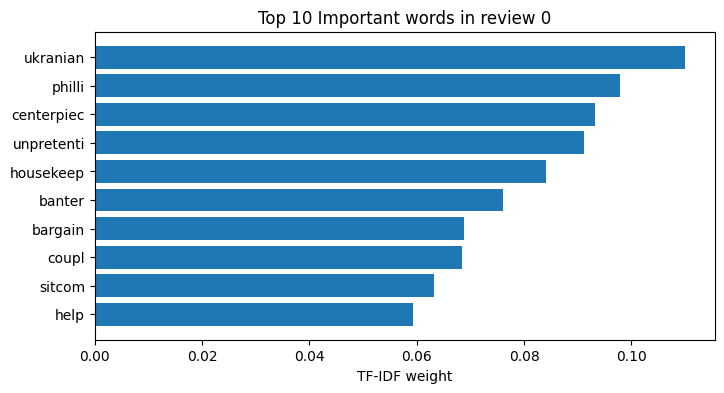

In [178]:
idx_to_word = {v:k for k,v in vocab.items()}

idx = 0 # change num for different review
print(X_train[idx])
row = X_train_tfidf[idx]
print("word : wieght")
for i,v in enumerate(row):
        if v > 0:
            print(idx_to_word[i], " : ", v)

row = X_train_tfidf[idx]

# top 10 words
top = 10
top_idx = np.argsort(row)[-1*top:]
top_words = [idx_to_word[i] for i in top_idx]
top_vals = row[top_idx]

plt.figure(figsize=(8,4))
plt.barh(top_words, top_vals)
plt.xlabel("TF-IDF weight")
plt.title(f"Top 10 Important words in review {idx}")
plt.show()

## Linear Regression

In [179]:
X_train = torch.tensor(X_train_tfidf, dtype=torch.float32)
X_test = torch.tensor(X_test_tfidf, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

n_features = X_train.shape[1]

weight = torch.zeros((n_features, 1), dtype=torch.float32, requires_grad=True)
bias = torch.zeros(1, dtype=torch.float32, requires_grad=True)

lr = 1.0
epochs = 1000
eps = 1e-8 # prevent 0

start = time.time()
for epoch in range(epochs):
    logits = X_train @ weight + bias
    sigmoid = 1 / (1 + torch.exp(-logits))

    loss = -(
        y_train * torch.log(sigmoid + eps) +
        (1 - y_train) * torch.log(1 - sigmoid + eps)
    ).mean()

    loss.backward()

    with torch.no_grad():
        weight -= lr * weight.grad
        bias -= lr * bias.grad

    weight.grad.zero_()
    bias.grad.zero_()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

end_train = time.time() - start

start = time.time()
with torch.no_grad():
    test_logits = X_test @ W + b
    test_probs = 1 / (1 + torch.exp(-test_logits))
    pred_label = (test_probs >= 0.5).float()
end_test = time.time() - start
    
pred_eval = evaluate_predictions(
    y_test.numpy().flatten(),
    pred_label.numpy().flatten(),
    model_name="TF-IDF + Linear Regression"
)

Epoch [10/1000], Loss: 0.6927
Epoch [20/1000], Loss: 0.6921
Epoch [30/1000], Loss: 0.6916
Epoch [40/1000], Loss: 0.6911
Epoch [50/1000], Loss: 0.6906
Epoch [60/1000], Loss: 0.6901
Epoch [70/1000], Loss: 0.6895
Epoch [80/1000], Loss: 0.6890
Epoch [90/1000], Loss: 0.6885
Epoch [100/1000], Loss: 0.6880
Epoch [110/1000], Loss: 0.6875
Epoch [120/1000], Loss: 0.6870
Epoch [130/1000], Loss: 0.6865
Epoch [140/1000], Loss: 0.6859
Epoch [150/1000], Loss: 0.6854
Epoch [160/1000], Loss: 0.6849
Epoch [170/1000], Loss: 0.6844
Epoch [180/1000], Loss: 0.6839
Epoch [190/1000], Loss: 0.6834
Epoch [200/1000], Loss: 0.6829
Epoch [210/1000], Loss: 0.6824
Epoch [220/1000], Loss: 0.6819
Epoch [230/1000], Loss: 0.6814
Epoch [240/1000], Loss: 0.6809
Epoch [250/1000], Loss: 0.6804
Epoch [260/1000], Loss: 0.6799
Epoch [270/1000], Loss: 0.6794
Epoch [280/1000], Loss: 0.6789
Epoch [290/1000], Loss: 0.6784
Epoch [300/1000], Loss: 0.6779
Epoch [310/1000], Loss: 0.6774
Epoch [320/1000], Loss: 0.6769
Epoch [330/1000],

In [180]:
print(f"\n===== {pred_eval["model"]} =====")
print(f"Train Time: {end_train}")
print(f"Test Time: {end_test}")
print(f"Accuracy : {pred_eval["accuracy"]:.4f}")
print(f"Precision: {pred_eval["precision"]:.4f}")
print(f"Recall   : {pred_eval["recall"]:.4f}")
print(f"F1-score : {pred_eval["f1"]:.4f}")



===== TF-IDF + Linear Regression =====
Train Time: 103.24814295768738
Test Time: 0.19029808044433594
Accuracy : 0.8479
Precision: 0.8284
Recall   : 0.8776
F1-score : 0.8523


Top positive features:
great                     0.1312
love                      0.1085
excel                     0.0865
best                      0.0811
enjoy                     0.0687
beauti                    0.0680
perform                   0.0584
favorit                   0.0545
well                      0.0543
perfect                   0.0527
amaz                      0.0499
brilliant                 0.0469
famili                    0.0462
life                      0.0451
also                      0.0450
wonder                    0.0450
music                     0.0436
show                      0.0431
fun                       0.0414
superb                    0.0409

Top negative features:
bad                       -0.1765
worst                     -0.1331
wast                      -0.1161
aw                        -0.0903
terribl                   -0.0871
bore                      -0.0833
stupid                    -0.0759
horribl                   -0.0720
noth                 

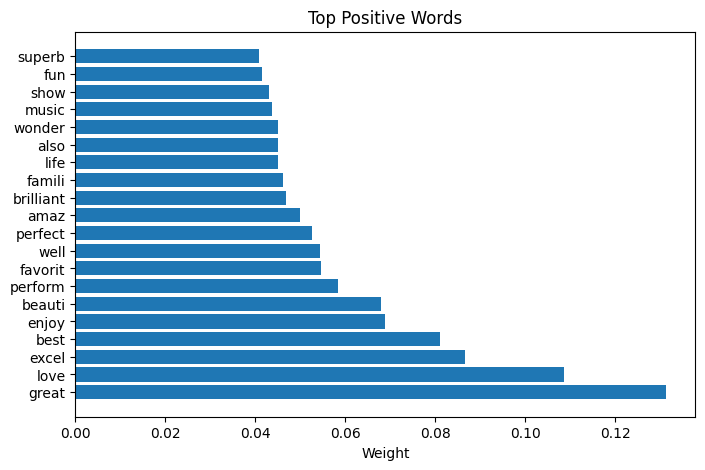

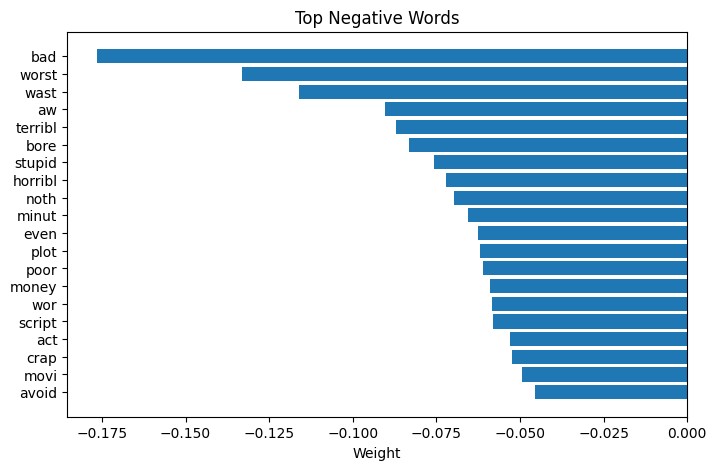

In [181]:
coefs = W.detach().numpy().flatten()

idx_to_word = {idx: word for word, idx in vocab.items()}

feature_names = np.array([idx_to_word[i] for i in range(len(idx_to_word))])

top = 20

top_positive_idx = np.argsort(coefs)[-1*top:]
top_negative_idx = np.argsort(coefs)[:top]

top_pos_words = feature_names[top_positive_idx]
top_pos_vals = coefs[top_positive_idx]

top_neg_words = feature_names[top_negative_idx]
top_neg_vals = coefs[top_negative_idx]

print("Top positive features:")
for idx in top_positive_idx[::-1]:
    print(f"{feature_names[idx]:<25} {coefs[idx]:.4f}")

print("\nTop negative features:")
for idx in top_negative_idx:
    print(f"{feature_names[idx]:<25} {coefs[idx]:.4f}")

# Positive chart
plt.figure(figsize=(8, 5))
plt.barh(top_pos_words[::-1], top_pos_vals[::-1])
plt.xlabel("Weight")
plt.title("Top Positive Words")
plt.show()

# Negative chart
plt.figure(figsize=(8, 5))
plt.barh(top_neg_words[::-1], top_neg_vals[::-1])
plt.xlabel("Weight")
plt.title("Top Negative Words")
plt.show()

## Demo

In [188]:
def sentence_to_tfidf(sentence, vocab, idf):
    words = tokenize(sentence)
    vec = np.zeros(len(vocab), dtype=np.float32)

    # term frequency for single sentence
    for w in words:
        if w in vocab:
            j = vocab[w]
            vec[j] += 1

    if len(words) > 0:
        vec = vec / len(words)
    
    vec = vec * idf
    return vec

def predict_sentence(sentence):
    vec = sentence_to_tfidf(sentence, vocab, idf)
    x = torch.tensor(vec, dtype=torch.float32).view(1, -1)

    with torch.no_grad():
        logits = x @ weight + bias
        prob = 1 / (1 + torch.exp(-logits))
        prob = prob.item()
        pred = 1 if prob >= 0.5 else 0

    label = "Positive" if pred == 1 else "Negative"
    return label, prob

while True:
    text = input("Enter a review (type 'quit' to stop): ")

    if text.lower() == "quit":
        break

    label, prob = predict_sentence(text)
    print(f"Input: {text}")
    print(f"Prediction: {label}")
    print(f"Probability: {prob:.4f}\n")

Input: hi
Prediction: Positive
Probability: 0.5282

Input: fuck up
Prediction: Positive
Probability: 0.5148

Input: fuky this
Prediction: Positive
Probability: 0.5040

Input: fuck this
Prediction: Negative
Probability: 0.4990

